In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split, Dataset
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

CONFIG = {
    "seed": 42,
    "image_size": 224,          # DINOv2 requires image dimensions to be multiples of 14
    "batch_size": 32,           # Increased because the backbone is frozen 
    "accum_steps": 1,           
    "num_workers": 2,
    "num_epochs": 100,           
    "learning_rate": 1e-3,      # A slightly higher LR works best for a 1-layer linear probe
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Dataset normalization  
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_val = datasets.ImageFolder(VAL_DIR)
full_dataset = ConcatDataset([raw_train, raw_val])

CLASS_TO_IDX = raw_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

total_len = len(full_dataset)
train_len = int(0.7 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

class TransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = TransformWrapper(train_subset, transform=train_transforms)
val_dataset = TransformWrapper(val_subset, transform=val_test_transforms)
test_dataset = TransformWrapper(test_subset, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

Using device: cuda


In [3]:
class DINOv2LinearProbe(nn.Module):
    def __init__(self, num_classes=2, backbone_name='dinov2_vitb14'):
        super().__init__()
        # Load the pre-trained DINOv2 backbone from PyTorch Hub
        self.backbone = torch.hub.load('facebookresearch/dinov2', backbone_name) #
        
        # Freeze the backbone completely so it acts purely as a feature extractor
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Get the embedding dimension (768 for vitb14)
        embed_dim = self.backbone.embed_dim #
        
        # Add a trainable linear classification head
        self.classifier = nn.Linear(embed_dim, num_classes)
        
    def forward(self, x):
        with torch.no_grad():
            # Extract frozen features (CLS token)
            features = self.backbone(x)
        # Pass the extracted features to the linear classifier
        return self.classifier(features)

# Initialize the model using the Base (vitb14) version
model = DINOv2LinearProbe(num_classes=2, backbone_name='dinov2_vitb14').to(DEVICE)

 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DINOv2 Linear Probe ready on {DEVICE}.")
print(f"Total Trainable Parameters: {num_trainable:,}") # This will be extremely low (~1,538 parameters)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]


DINOv2 Linear Probe ready on cuda.
Total Trainable Parameters: 1,538


In [4]:
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
CHECKPOINT_PATH = "/kaggle/working/checkpoints/dinov2_probe_best.pth"

best_val_loss = float("inf")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
start_time = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels) / CONFIG["accum_steps"]
        loss.backward()

        if (step + 1) % CONFIG["accum_steps"] == 0 or (step + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * CONFIG["accum_steps"] * images.size(0)
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()
        running_total += images.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += images.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.1f} min. Best val_loss: {best_val_loss:.4f}")

# Reload best checkpoint for evaluation
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

Epoch 001/100 | train_loss=0.5733 train_acc=0.7086 | val_loss=0.3875 val_acc=0.8387
Epoch 002/100 | train_loss=0.3330 train_acc=0.8571 | val_loss=0.3359 val_acc=0.8627
Epoch 003/100 | train_loss=0.2855 train_acc=0.8854 | val_loss=0.3175 val_acc=0.8613
Epoch 004/100 | train_loss=0.2595 train_acc=0.8923 | val_loss=0.3157 val_acc=0.8693
Epoch 005/100 | train_loss=0.2426 train_acc=0.9043 | val_loss=0.3140 val_acc=0.8747
Epoch 006/100 | train_loss=0.2305 train_acc=0.9040 | val_loss=0.3169 val_acc=0.8733
Epoch 007/100 | train_loss=0.2235 train_acc=0.9103 | val_loss=0.3229 val_acc=0.8693
Epoch 008/100 | train_loss=0.2188 train_acc=0.9131 | val_loss=0.3266 val_acc=0.8720
Epoch 009/100 | train_loss=0.2164 train_acc=0.9171 | val_loss=0.3314 val_acc=0.8600
Epoch 010/100 | train_loss=0.2108 train_acc=0.9134 | val_loss=0.3369 val_acc=0.8693
Epoch 011/100 | train_loss=0.2045 train_acc=0.9200 | val_loss=0.3432 val_acc=0.8680
Epoch 012/100 | train_loss=0.1853 train_acc=0.9300 | val_loss=0.3408 val_acc

<All keys matched successfully>

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

          ai       0.81      0.90      0.85       370
      nature       0.89      0.79      0.84       380

    accuracy                           0.84       750
   macro avg       0.85      0.84      0.84       750
weighted avg       0.85      0.84      0.84       750



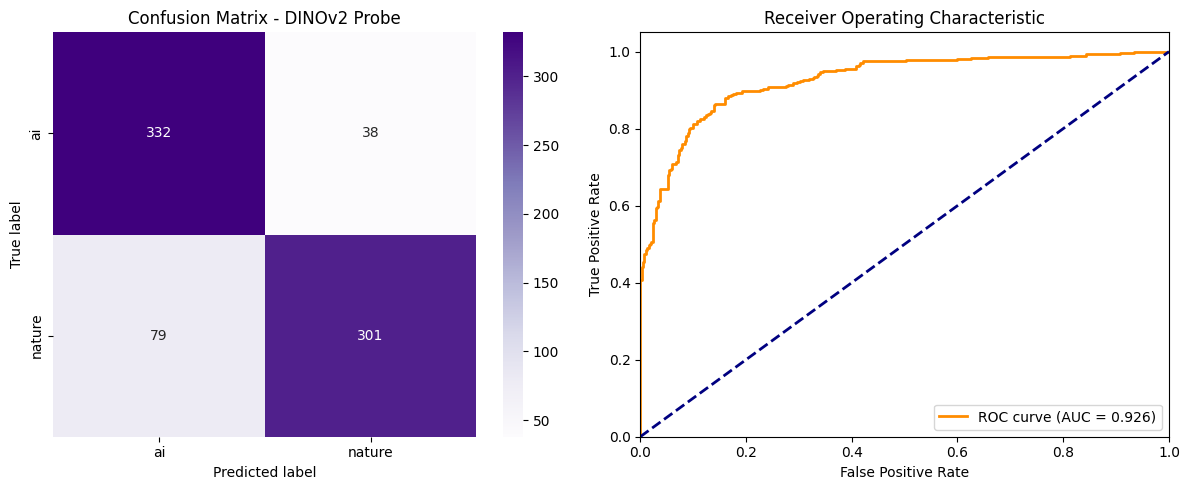

In [5]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        # Get probabilities for the positive class
        pos_idx = CLASS_TO_IDX.get("ai", 0)
        probs = torch.softmax(outputs, dim=1)[:, pos_idx].cpu().tolist()
        preds = outputs.argmax(dim=1).cpu().tolist()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

print("===== Classification Report (Test Set) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[0])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix - DINOv2 Probe")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=pos_idx)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [6]:
output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
pos_lbl = CLASS_TO_IDX.get("ai", 0)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_lbl
)

results_row = {
    "dataset": "tiny_genimage_wukong",
    "model": "dinov2_vitb14_probe",
    "num_epochs": CONFIG["num_epochs"],
    "train_images": len(train_dataset),
    "test_images": len(test_dataset),
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
display(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "dinov2_probe_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "dinov2_probe_best_model.pth")
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

,dataset,model,num_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_wukong,dinov2_vitb14_probe,100,3500,750,0.844,0.8078,0.8973,0.8502,0.9263



===== Download Links =====


/kaggle/working/results/dinov2_probe_test_results.csv

/kaggle/working/results/dinov2_probe_best_model.pth